# Soal Nomor 2 — Taylor Series Expansion

**Masalah:** Model polinomial dari Soal 1 perlu diaproksimasi di sekitar titik tertentu menggunakan deret Taylor.

**Tujuan:** Membandingkan aproksimasi Taylor dengan jumlah suku berbeda (1–4 suku) terhadap model asli, dan menganalisis error-nya.

**Metode:** Deret Taylor

**Alasan:** Deret Taylor digunakan untuk mengekspresikan fungsi sebagai jumlah polinomial dari turunan-turunannya di suatu titik. Semakin banyak suku yang digunakan, aproksimasi semakin akurat. Pusat ekspansi dipilih di t = 72 (titik tengah data) agar error merata ke kedua arah.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
data = pd.read_excel('aol_data.xlsx')
x = np.arange(1, 145)
y = data.values[0]

a3, a2, a1, a0 = np.polyfit(x, y, 3)
model_polinomial = np.poly1d([a3, a2, a1, a0])

print(f"Model: P(t) = {a3:.3f}t\u00b3 + {a2:.3f}t\u00b2 + {a1:.3f}t + {a0:.3f}")

Model: P(t) = 0.004t³ + -0.134t² + 47.224t + 1748.507


## Ekspansi Taylor Derajat 3

Ekspansi Taylor derajat 3 membutuhkan nilai fungsi dan turunan pertama, kedua, serta ketiga di titik pusat t = 72. Setiap turunan dihitung secara analitis dari koefisien polinomial. Ekspansi dengan N suku akan melibatkan nilai fungsi di titik pusat ditambah koreksi dari turunan-turunan yang semakin tinggi.

Selanjutnya kita hitung aproksimasi dengan 1, 2, 3, dan 4 suku, lalu bandingkan error-nya.

In [28]:
t = 72

P_0 = a3*t**3 + a2*t**2 + a1*t + a0
P_1 = 3*a3*t**2 + 2*a2*t + a1
P_2 = 6*a3*t + 2*a2
P_3 = 6*a3

print("\nEkspansi Taylor derajat 3 di sekitar t =", t)
print(f"P(t) = {P_0:.3f} + {P_1:.3f}(t-{t}) + {P_2/2:.3f}(t-{t})\u00b2 + {P_3/6:.3f}(t-{t})\u00b3")


Ekspansi Taylor derajat 3 di sekitar t = 72
P(t) = 5894.053 + 87.958(t-72) + 0.700(t-72)² + 0.004(t-72)³


In [29]:
def taylor_ke(selisih_waktu, N):
    if N == 1:
        return P_0
    elif N == 2:
        return P_0 + P_1 * selisih_waktu
    elif N == 3:
        return P_0 + P_1 * selisih_waktu + P_2/2 * selisih_waktu**2
    elif N == 4:
        return P_0 + P_1 * selisih_waktu + P_2/2 * selisih_waktu**2 + P_3/6 * selisih_waktu**3

nilai_asli = model_polinomial(x)

taylor_1 = np.array([taylor_ke(i - t, 1) for i in x])
taylor_2 = np.array([taylor_ke(i - t, 2) for i in x])
taylor_3 = np.array([taylor_ke(i - t, 3) for i in x])
taylor_4 = np.array([taylor_ke(i - t, 4) for i in x])

error_1 = np.abs(nilai_asli - taylor_1)
error_2 = np.abs(nilai_asli - taylor_2)
error_3 = np.abs(nilai_asli - taylor_3)
error_4 = np.abs(nilai_asli - taylor_4)

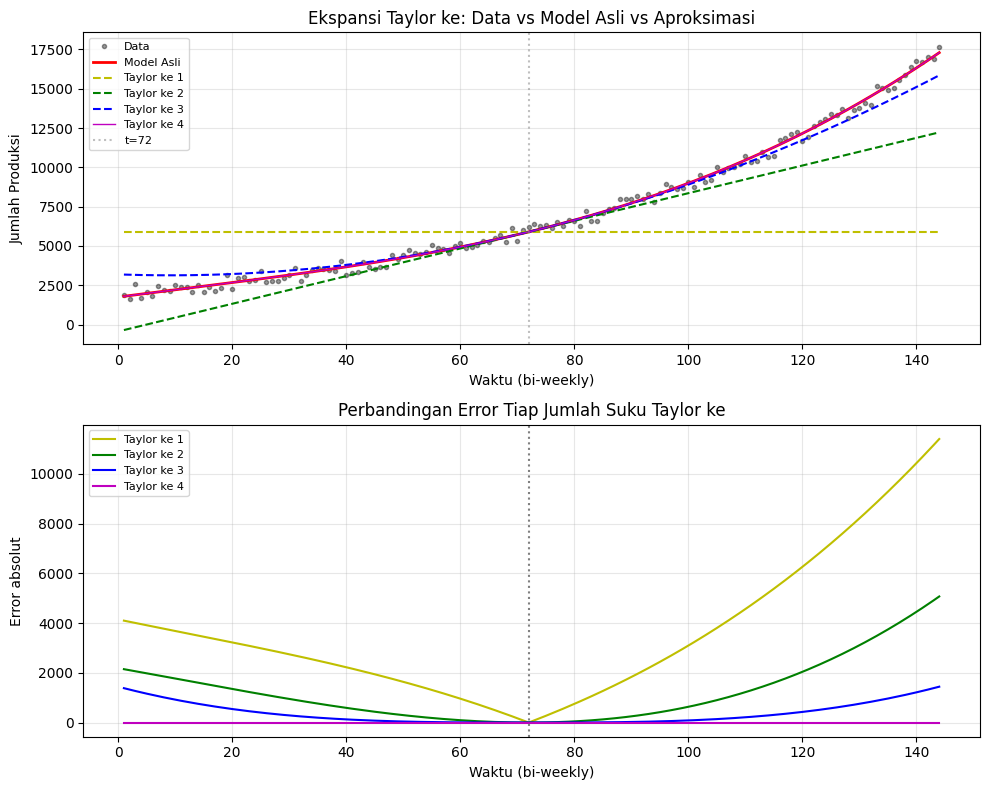

In [30]:
fig, (gambar_atas, gambar_bawah) = plt.subplots(2, 1, figsize=(10, 8))

gambar_atas.plot(x, y, 'k.', label='Data', alpha=0.4)
gambar_atas.plot(x, nilai_asli, 'r-', label='Model Asli', linewidth=2)
gambar_atas.plot(x, taylor_1, 'y--', label='Taylor ke 1')
gambar_atas.plot(x, taylor_2, 'g--', label='Taylor ke 2')
gambar_atas.plot(x, taylor_3, 'b--', label='Taylor ke 3')
gambar_atas.plot(x, taylor_4, 'm-', label='Taylor ke 4', linewidth=1)
gambar_atas.axvline(t, color='gray', linestyle=':', alpha=0.5, label=f't={t}')
gambar_atas.set_xlabel('Waktu (bi-weekly)')
gambar_atas.set_ylabel('Jumlah Produksi')
gambar_atas.set_title('Ekspansi Taylor ke: Data vs Model Asli vs Aproksimasi')
gambar_atas.legend(fontsize=8)
gambar_atas.grid(True, alpha=0.3)

gambar_bawah.plot(x, error_1, 'y-', label='Taylor ke 1')
gambar_bawah.plot(x, error_2, 'g-', label='Taylor ke 2')
gambar_bawah.plot(x, error_3, 'b-', label='Taylor ke 3')
gambar_bawah.plot(x, error_4, 'm-', label='Taylor ke 4')
gambar_bawah.axvline(t, color='gray', linestyle=':')
gambar_bawah.set_xlabel('Waktu (bi-weekly)')
gambar_bawah.set_ylabel('Error absolut')
gambar_bawah.set_title('Perbandingan Error Tiap Jumlah Suku Taylor ke')
gambar_bawah.legend(fontsize=8)
gambar_bawah.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()